In [1]:
import pandas as pd

property = pd.read_csv("../data/datasets/property.csv")
rent = pd.read_csv("../data/datasets/rent.csv")

# Filtering Ohio
property_oh = property[property["State"]=="OH"]
rent_oh = rent[rent["State"]=="OH"]

print(property_oh.head)
print(rent_oh.head)

<bound method NDFrame.head of        RegionID  SizeRank  RegionName RegionType StateName State  \
198       77400       204       45011        zip        OH    OH   
281       76511       288       43081        zip        OH    OH   
297       76534       304       43123        zip        OH    OH   
305       77094       312       44256        zip        OH    OH   
367       76953       376       44035        zip        OH    OH   
...         ...       ...         ...        ...       ...   ...   
26255     77617     39992       45358        zip        OH    OH   
26267     77865     39992       45859        zip        OH    OH   
26273     76723     39992       43525        zip        OH    OH   
26286     77573     39992       45310        zip        OH    OH   
26290     77590     39992       45328        zip        OH    OH   

                City                 Metro       CountyName     2000-01-31  \
198         Hamilton  Cincinnati, OH-KY-IN    Butler County  132360.961886 

In [3]:
latest_price = property_oh.columns[-1]
latest_rent = rent_oh.columns[-1]

property_clean = property_oh[["RegionName", latest_price]]
rent_clean = rent_oh[["RegionName", latest_rent]]

property_clean.columns = ["zip", "price"]
rent_clean.columns = ["zip", "rent"]

In [4]:
df = pd.merge(property_clean, rent_clean, on='zip')
df['zip'] = df['zip'].astype(str)
df

,zip,price,rent
0,45011,355829.695700,1951.777778
1,43081,345430.893507,1546.159901
2,43123,320393.600458,1667.120261
3,44256,361791.741200,1876.427778
4,44035,177385.681885,1018.100000
...,...,...,...
242,45226,448692.127110,1704.500000
243,43222,157049.472656,1285.833333
244,45065,360020.334917,2218.388889
245,44304,92023.089642,947.500000


In [5]:
df["ROI"] = (df["rent"]*12) / df["price"] * 100
df

,zip,price,rent,ROI
0,45011,355829.695700,1951.777778,6.582175
1,43081,345430.893507,1546.159901,5.371239
2,43123,320393.600458,1667.120261,6.244021
3,44256,361791.741200,1876.427778,6.223783
4,44035,177385.681885,1018.100000,6.887365
...,...,...,...,...
242,45226,448692.127110,1704.500000,4.558582
243,43222,157049.472656,1285.833333,9.824930
244,45065,360020.334917,2218.388889,7.394212
245,44304,92023.089642,947.500000,12.355595


In [6]:
income = pd.read_csv("../data/datasets/income.csv")

# Clear median income data [zip, median_income]
income = income.iloc[1:]
income = income[["NAME", "B19013_001E"]]
income.columns = ["zip", "median_income"]
income["zip"] = income["zip"].str[-5:]
income_in = income[income["zip"].isin(df["zip"])]

income

,zip,median_income
1,00601,19454
2,00602,21420
3,00603,20933
4,00606,20992
5,00610,24496
...,...,...
33768,99923,-
33769,99925,61250
33770,99926,72279
33771,99927,-


In [7]:
# [zip, price, rent, ROI, median_price]
investment_df = pd.merge(df, income, on="zip", how="left")
investment_df

,zip,price,rent,ROI,median_income
0,45011,355829.695700,1951.777778,6.582175,91873
1,43081,345430.893507,1546.159901,5.371239,92422
2,43123,320393.600458,1667.120261,6.244021,91008
3,44256,361791.741200,1876.427778,6.223783,99923
4,44035,177385.681885,1018.100000,6.887365,56408
...,...,...,...,...,...
242,45226,448692.127110,1704.500000,4.558582,97558
243,43222,157049.472656,1285.833333,9.824930,32321
244,45065,360020.334917,2218.388889,7.394212,104795
245,44304,92023.089642,947.500000,12.355595,41763


zip                  str
price            float64
rent             float64
ROI              float64
median_income        str
dtype: object

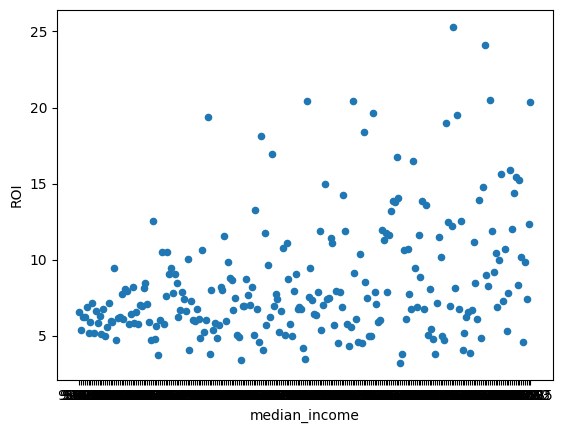

In [8]:
# Relation ROI vs income
investment_df.plot.scatter(x="median_income", y="ROI")
investment_df.dtypes

In [9]:
mortgage_rate = 0.065
investment_df["annual_mortgage_interest_cost"] = investment_df["price"]*mortgage_rate
investment_df[["zip","price","annual_mortgage_interest_cost"]].head()

,zip,price,annual_mortgage_interest_cost
0,45011,355829.695700,23128.930220
1,43081,345430.893507,22453.008078
2,43123,320393.600458,20825.584030
3,44256,361791.741200,23516.463178
4,44035,177385.681885,11530.069323


In [10]:
investment_df["cash_flow"] = (
    investment_df['rent']*12
  - investment_df["annual_mortgage_interest_cost"]
)
investment_df[["zip","annual_mortgage_interest_cost","cash_flow"]].head()

,zip,annual_mortgage_interest_cost,cash_flow
0,45011,23128.930220,292.403113
1,43081,22453.008078,-3899.089261
2,43123,20825.584030,-820.140892
3,44256,23516.463178,-999.329845
4,44035,11530.069323,687.130677


In [11]:
investment_df["ROI_after_interest"] = (
    investment_df["cash_flow"] / investment_df["price"]
)

investment_df[["zip","ROI","ROI_after_interest"]].head()

,zip,ROI,ROI_after_interest
0,45011,6.582175,0.000822
1,43081,5.371239,-0.011288
2,43123,6.244021,-0.002560
3,44256,6.223783,-0.002762
4,44035,6.887365,0.003874


In [12]:
investment_df["median_income"] = pd.to_numeric(investment_df["median_income"], errors="coerce")

investment_df[
    (investment_df["ROI"] > 0.08) &
    (investment_df["median_income"] > 50000)
].sort_values("ROI", ascending=False)

,zip,price,rent,ROI,median_income,annual_mortgage_interest_cost,cash_flow,ROI_after_interest
134,44137,126155.734302,1574.166667,14.973556,53918,8200.122730,10689.877270,0.084736
96,44125,134475.007555,1485.297619,13.254189,57363,8740.875491,9082.695937,0.067542
201,44301,115361.121464,1200.972222,12.492655,51321,7498.472895,6913.193771,0.059927
165,45414,173140.818796,1724.755556,11.953892,54485,11254.153222,9442.913445,0.054539
145,44305,116445.267467,1152.777778,11.879687,52768,7568.942385,6264.390948,0.053797
...,...,...,...,...,...,...,...,...
71,43035,496376.169472,1569.005952,3.793105,154683,32264.451016,-13436.379587,-0.027069
43,43017,560415.908500,1729.703704,3.703757,135922,36427.034052,-15670.589608,-0.027962
123,43054,557862.916488,1605.918301,3.454436,148100,36261.089572,-16990.069964,-0.030456
88,43082,530180.903926,1515.531746,3.430222,147972,34461.758755,-16275.377803,-0.030698


In [13]:
def z(s):
    return (s - s.mean()) / s.std(ddof=0)

# Standardized column
investment_df["z_roi_ai"] = z(investment_df["ROI_after_interest"])
investment_df["z_income"] = z(investment_df["median_income"])
investment_df["z_price"]  = z(investment_df["price"])

# 3) Investment Score (가중치: ROI 0.5, Income 0.3, Price(낮을수록 좋음) 0.2)
investment_df["investment_score"] = (
    0.5 * investment_df["z_roi_ai"]
    + 0.3 * investment_df["z_income"]
    - 0.2 * investment_df["z_price"]
)

investment_df[["zip","ROI_after_interest","median_income","price","investment_score"]].head()

,zip,ROI_after_interest,median_income,price,investment_score
0,45011,0.000822,91873,355829.695700,-0.208260
1,43081,-0.011288,92422,345430.893507,-0.336474
2,43123,-0.002560,91008,320393.600458,-0.198720
3,44256,-0.002762,99923,361791.741200,-0.175361
4,44035,0.003874,56408,177385.681885,-0.249024


In [14]:
top10 = investment_df.sort_values(
    "investment_score", ascending=False
).head(10)

top10[["zip","price","rent","ROI_after_interest","median_income","investment_score"]]

,zip,price,rent,ROI_after_interest,median_income,investment_score
221,45402,71775.242152,1443.313420,0.176306,48401,2.015336
204,43608,47164.483689,994.666667,0.188072,29275,1.996210
124,43605,61973.141908,1053.966667,0.139082,39118,1.462327
224,44502,53297.964668,911.250000,0.140167,31170,1.403835
149,44108,72308.762290,1231.777778,0.139420,34745,1.400633
160,43607,72781.836092,1189.583333,0.131134,41335,1.367913
246,44704,70496.908549,1195.000000,0.138413,31812,1.358937
70,44105,72215.075628,1164.790909,0.128554,40906,1.331734
206,44485,67611.457078,1100.000000,0.130233,35195,1.298189
155,43609,67574.340940,1035.055556,0.118807,42313,1.232654


<Axes: xlabel='median_income', ylabel='investment_score'>

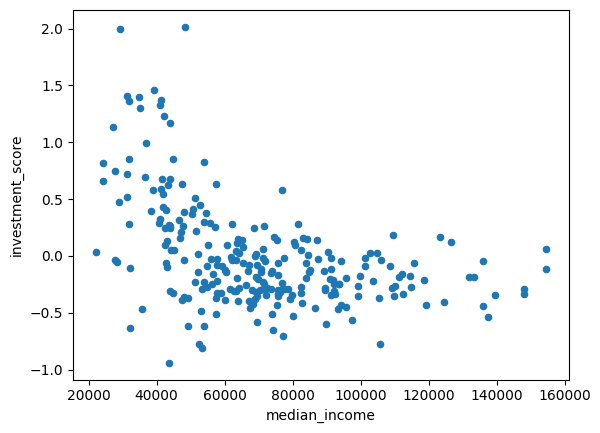

In [15]:
investment_df.plot.scatter(
    x="median_income",
    y="investment_score"
)

In [16]:
investment_df.to_csv("ohio_real_estate_investment.csv", index=False)

In [17]:
ohio_df = investment_df